# ✈️ CO2 Emissions from Aviation — Enhanced ML & Forecasting Pipeline

**SkyInsight | ESPRIT 3ALINFO **

## Enhanced Workflow
1. Setup & Imports  
2. Data Loading  
3. Data Understanding  
4. Data Cleaning  
5. Exploratory Data Analysis (EDA)  
6. Advanced Feature Engineering  
7. Time-Based Data Preparation  
8. Multi-Model Training & Tuning  
   - Linear Regression (baseline)  
   - Ridge & Lasso (regularized)  
   - Random Forest (tuned)  
   - Gradient Boosting (XGBoost-style)  
   - SVR  
   - ARIMA (univariate TS)  
   - Exponential Smoothing (Holt-Winters)  
   - Prophet (if available)  
9. Evaluation & Model Comparison  
10. Ensemble / Stacking  
11. 10-Year Forecasting  
12. Anomaly Detection  
13. Feature Importance  
14. Multi-Country Comparison  
15. Insights & Conclusion  

In [24]:
# ═══════════════════════════════════════════════════════════
# 1) SETUP & IMPORTS
# ═══════════════════════════════════════════════════════════
import os
import warnings
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# --- Sklearn ---
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    StackingRegressor,
    VotingRegressor,
)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
)
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

# --- Statsmodels ---
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# --- Optional: Prophet ---
try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
except Exception:
    PROPHET_AVAILABLE = False

# --- Optional: XGBoost ---
try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False

# --- Optional: LightGBM ---
try:
    from lightgbm import LGBMRegressor
    LGBM_AVAILABLE = True
except Exception:
    LGBM_AVAILABLE = False

warnings.filterwarnings("ignore")

# Styling
sns.set_theme(style="whitegrid", context="talk", palette="husl")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13
COLORS = sns.color_palette("husl", 12)

print(f"Prophet   available: {PROPHET_AVAILABLE}")
print(f"XGBoost   available: {XGBOOST_AVAILABLE}")
print(f"LightGBM  available: {LGBM_AVAILABLE}")
print("Setup complete ✅")

Prophet   available: False
XGBoost   available: False
LightGBM  available: False
Setup complete ✅


In [25]:
# ═══════════════════════════════════════════════════════════
# 2) DATA LOADING
# ═══════════════════════════════════════════════════════════
DATA_PATH = "annual-co-emissions-from-aviation.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found at '{DATA_PATH}'.\n"
        "Place the notebook in the same folder as the CSV, or update DATA_PATH."
    )

df_raw = pd.read_csv(DATA_PATH)

print("First 5 rows:")
display(df_raw.head())
print(f"\nDataset shape: {df_raw.shape}")
print("Columns:", df_raw.columns.tolist())

First 5 rows:


,Entity,Code,Year,Total annual CO₂ emissions from aviation
0,Afghanistan,AFG,2013,208656.12
1,Afghanistan,AFG,2014,227078.30
2,Afghanistan,AFG,2015,187643.45
3,Afghanistan,AFG,2016,177195.73
4,Afghanistan,AFG,2017,204241.47



Dataset shape: (1605, 4)
Columns: ['Entity', 'Code', 'Year', 'Total annual CO₂ emissions from aviation']


In [26]:
# ═══════════════════════════════════════════════════════════
# 3) DATA UNDERSTANDING
# ═══════════════════════════════════════════════════════════
print("Data types:")
display(df_raw.dtypes.to_frame("dtype"))

print("\nSummary statistics:")
display(df_raw.describe(include="all").T)

print("\nMissing values per column:")
missing_df = df_raw.isna().sum().to_frame("missing_count")
missing_df["missing_pct"] = (missing_df["missing_count"] / len(df_raw) * 100).round(2)
display(missing_df.sort_values("missing_count", ascending=False))

Data types:


,dtype
Entity,object
Code,object
Year,int64
Total annual CO₂ emissions from aviation,float64



Summary statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Entity,1605,171,Africa,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Code,1599,170,OWID_AFR,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,1605.0,NaN,NaN,NaN,2018.257944,3.460249,2013.0,2015.0,2018.0,2021.0,2024.0
Total annual CO₂ emissions from aviation,1605.0,NaN,NaN,NaN,14209594.177289,59769910.890148,2929.3525,205469.61,875032.3,4384410.0,863242600.0



Missing values per column:


,missing_count,missing_pct
Code,6,0.37
Entity,0,0.00
Year,0,0.00
Total annual CO₂ emissions from aviation,0,0.00


In [27]:
# ═══════════════════════════════════════════════════════════
# 4) DATA CLEANING
# ═══════════════════════════════════════════════════════════
def clean_emissions_data(df: pd.DataFrame) -> pd.DataFrame:
    """Clean and standardize the raw emissions dataframe."""
    cleaned = df.copy()

    rename_map = {
        "Entity": "Country",
        "Code": "CountryCode",
        "Year": "Year",
        "Total annual CO2 emissions from aviation": "Emissions",
        "Total annual CO\u2082 emissions from aviation": "Emissions",
    }
    cleaned = cleaned.rename(columns=rename_map)

    required_cols = ["Country", "Year", "Emissions"]
    missing_required = [c for c in required_cols if c not in cleaned.columns]
    if missing_required:
        raise ValueError(f"Missing required columns after rename: {missing_required}")

    cleaned["Country"] = cleaned["Country"].astype(str).str.strip()
    cleaned["Year"] = pd.to_numeric(cleaned["Year"], errors="coerce")
    cleaned["Emissions"] = pd.to_numeric(cleaned["Emissions"], errors="coerce")

    cleaned = cleaned.dropna(subset=["Country", "Year", "Emissions"]).copy()
    cleaned["Year"] = cleaned["Year"].astype(int)

    cleaned = cleaned.drop_duplicates(subset=["Country", "Year"], keep="last")
    cleaned = cleaned.sort_values(["Country", "Year"]).reset_index(drop=True)

    return cleaned

df = clean_emissions_data(df_raw)
print(f"Cleaned shape: {df.shape}")
display(df.head())

Cleaned shape: (1605, 4)


,Country,CountryCode,Year,Emissions
0,Afghanistan,AFG,2013,208656.12
1,Afghanistan,AFG,2014,227078.30
2,Afghanistan,AFG,2015,187643.45
3,Afghanistan,AFG,2016,177195.73
4,Afghanistan,AFG,2017,204241.47


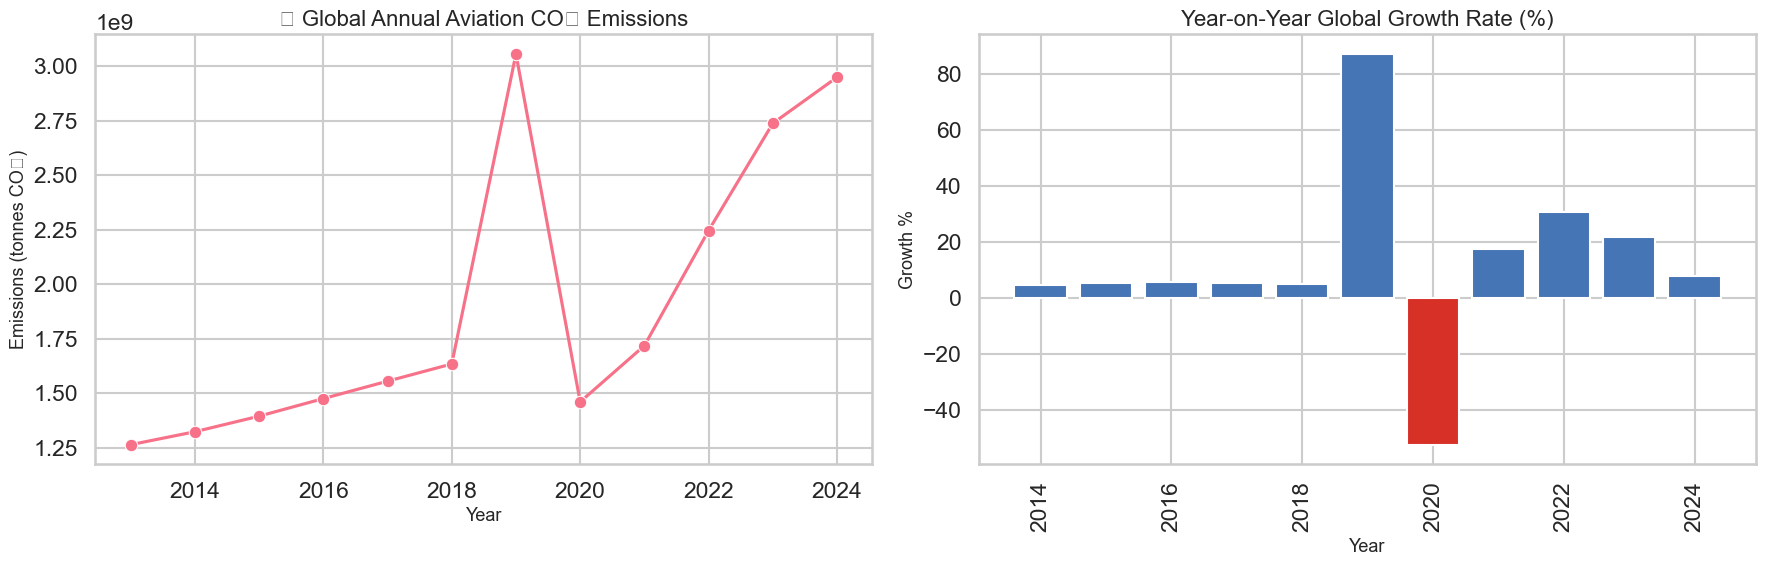

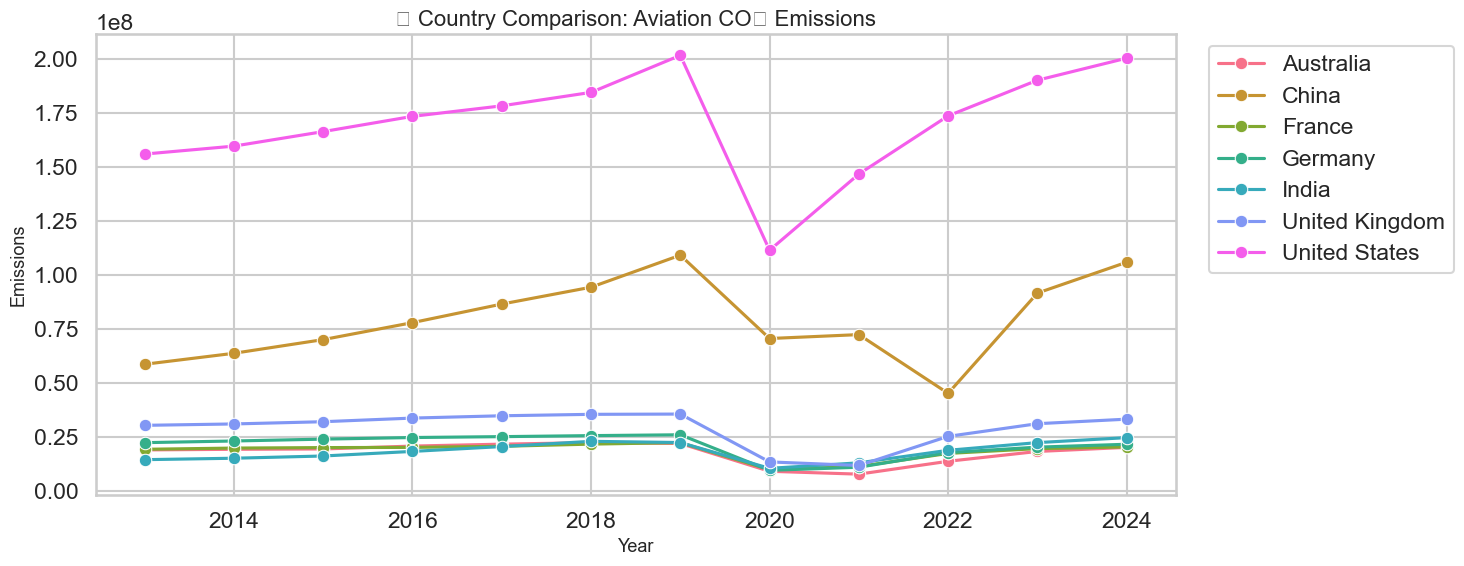

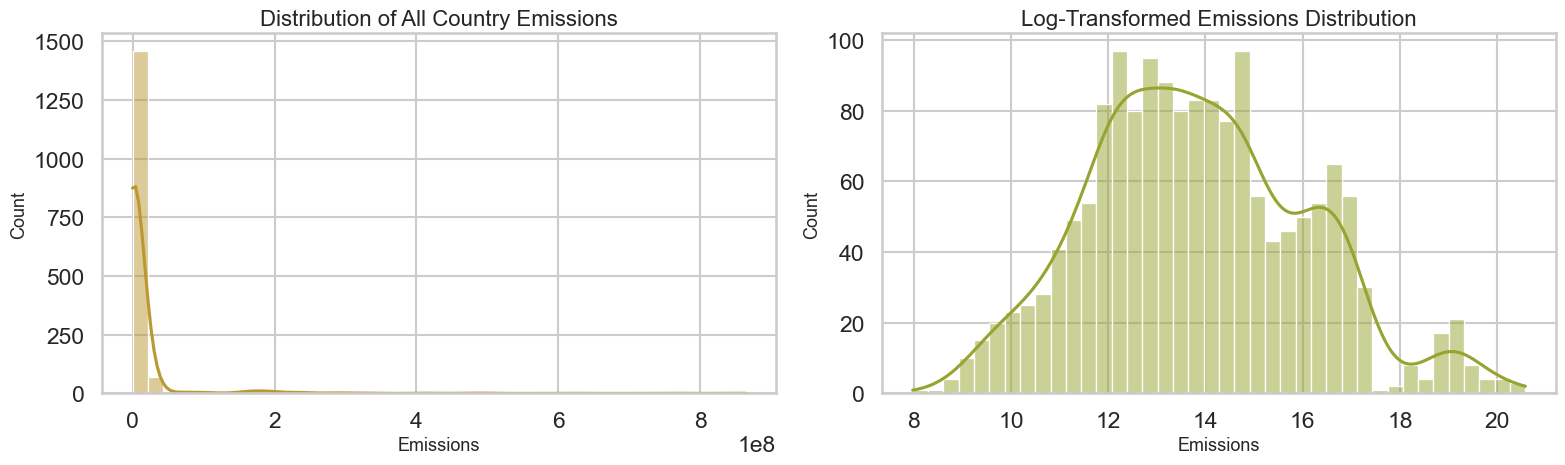


📊 Summary Stats (Global):


,Year,Emissions
count,12.000000,1.200000e+01
mean,2018.500000,1.900533e+09
std,3.605551,6.638232e+08
min,2013.000000,1.263311e+09
25%,2015.750000,1.443275e+09
50%,2018.500000,1.594026e+09
75%,2021.250000,2.368326e+09
max,2024.000000,3.055384e+09


In [28]:
# ═══════════════════════════════════════════════════════════
# 5) EXPLORATORY DATA ANALYSIS (EDA)
# ═══════════════════════════════════════════════════════════

# --- 5a) Global Annual Trend ---
global_by_year = df.groupby("Year", as_index=False)["Emissions"].sum()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.lineplot(ax=axes[0], data=global_by_year, x="Year", y="Emissions", marker="o", color=COLORS[0])
axes[0].set_title("🌍 Global Annual Aviation CO₂ Emissions")
axes[0].set_ylabel("Emissions (tonnes CO₂)")

# Growth rate
bars_df = global_by_year.copy()
bars_df["Growth_pct"] = bars_df["Emissions"].pct_change() * 100
bars_df = bars_df.dropna()

bar_colors = ["#d73027" if v < 0 else "#4575b4" for v in bars_df["Growth_pct"]]
axes[1].bar(bars_df["Year"].astype(int), bars_df["Growth_pct"], color=bar_colors)
axes[1].set_title("Year-on-Year Global Growth Rate (%)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Growth %")

# Reduce tick density for faster rendering
if len(bars_df) > 20:
    step = max(1, len(bars_df) // 10)
    axes[1].set_xticks(bars_df["Year"].astype(int).iloc[::step])

axes[1].tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

# --- 5b) Top Countries ---
preferred = ["United States", "China", "India", "United Kingdom", "Germany", "France", "Australia"]
available = [c for c in preferred if c in df["Country"].unique()]
if len(available) < 3:
    available = (
        df.groupby("Country")["Emissions"].mean()
        .sort_values(ascending=False).head(6).index.tolist()
    )

subset = df[df["Country"].isin(available)].copy()
plt.figure(figsize=(15, 6))
sns.lineplot(data=subset, x="Year", y="Emissions", hue="Country", marker="o")
plt.title("🛫 Country Comparison: Aviation CO₂ Emissions")
plt.ylabel("Emissions")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# --- 5c) Distribution of Emissions ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(df["Emissions"], bins=40, kde=True, ax=axes[0], color=COLORS[2])
axes[0].set_title("Distribution of All Country Emissions")
sns.histplot(np.log1p(df["Emissions"]), bins=40, kde=True, ax=axes[1], color=COLORS[3])
axes[1].set_title("Log-Transformed Emissions Distribution")
plt.tight_layout()
plt.show()

# --- 5d) Correlation heatmap (numerical columns) ---
print("\n📊 Summary Stats (Global):")
display(global_by_year.describe())

In [29]:
# ═══════════════════════════════════════════════════════════
# 6) ADVANCED FEATURE ENGINEERING
# ═══════════════════════════════════════════════════════════
def add_features(clean_df: pd.DataFrame) -> pd.DataFrame:
    """Rich feature set for supervised ML models."""
    feat = clean_df.copy().sort_values(["Country", "Year"]).reset_index(drop=True)
    grp = feat.groupby("Country")

    # Lag features
    feat["Emissions_Lag1"] = grp["Emissions"].shift(1)
    feat["Emissions_Lag2"] = grp["Emissions"].shift(2)
    feat["Emissions_Lag3"] = grp["Emissions"].shift(3)

    # Growth rates
    feat["YoY_Growth"] = grp["Emissions"].pct_change() * 100
    feat["Growth_Lag1"] = grp["YoY_Growth"].shift(1) if "YoY_Growth" in feat.columns else 0.0

    # Rolling statistics
    feat["Rolling_3Y_Avg"] = grp["Emissions"].transform(lambda x: x.rolling(3, min_periods=1).mean())
    feat["Rolling_5Y_Avg"] = grp["Emissions"].transform(lambda x: x.rolling(5, min_periods=1).mean())
    feat["Rolling_3Y_Std"] = grp["Emissions"].transform(lambda x: x.rolling(3, min_periods=2).std().fillna(0))

    # Momentum
    feat["Momentum_2Y"] = feat["Emissions_Lag1"] - feat["Emissions_Lag2"]

    # Log-emissions (helpful for skewed data)
    feat["Log_Emissions"] = np.log1p(feat["Emissions"])
    feat["Log_Lag1"] = np.log1p(feat["Emissions_Lag1"].clip(lower=0))

    # Year features (cyclical & polynomial)
    min_year = feat["Year"].min()
    feat["Year_Idx"] = feat["Year"] - min_year          # zero-indexed
    feat["Year_Sq"] = feat["Year_Idx"] ** 2             # quadratic trend

    # Fill early YoY NaNs
    feat["YoY_Growth"] = feat["YoY_Growth"].fillna(0.0)
    feat["Growth_Lag1"] = feat["Growth_Lag1"].fillna(0.0)
    feat["Momentum_2Y"] = feat["Momentum_2Y"].fillna(0.0)

    return feat

df_feat = add_features(df)
print(f"Feature-engineered shape: {df_feat.shape}")
display(df_feat.head(10))

Feature-engineered shape: (1605, 17)


,Country,CountryCode,Year,Emissions,Emissions_Lag1,Emissions_Lag2,Emissions_Lag3,YoY_Growth,Growth_Lag1,Rolling_3Y_Avg,Rolling_5Y_Avg,Rolling_3Y_Std,Momentum_2Y,Log_Emissions,Log_Lag1,Year_Idx,Year_Sq
0,Afghanistan,AFG,2013,208656.120,NaN,NaN,NaN,0.000000,0.000000,208656.120000,208656.120000,0.000000,0.000,12.248448,NaN,0,0
1,Afghanistan,AFG,2014,227078.300,208656.120,NaN,NaN,8.828967,0.000000,217867.210000,217867.210000,13026.448402,0.000,12.333055,12.248448,1,1
2,Afghanistan,AFG,2015,187643.450,227078.300,208656.120,NaN,-17.366190,8.828967,207792.623333,207792.623333,19731.600759,18422.180,12.142304,12.333055,2,4
3,Afghanistan,AFG,2016,177195.730,187643.450,227078.300,208656.12,-5.567858,-17.366190,197305.826667,200143.400000,26307.581409,-39434.850,12.085016,12.142304,3,9
4,Afghanistan,AFG,2017,204241.470,177195.730,187643.450,227078.30,15.263201,-5.567858,189693.550000,200963.014000,13638.922081,-10447.720,12.227063,12.085016,4,16
5,Afghanistan,AFG,2018,236053.940,204241.470,177195.730,187643.45,15.575911,15.263201,205830.380000,206442.578000,29461.257566,27045.740,12.371820,12.227063,5,25
6,Afghanistan,AFG,2019,159873.330,236053.940,204241.470,177195.73,-32.272543,15.575911,200056.246667,193001.584000,38262.362783,31812.470,11.982143,12.371820,6,36
7,Afghanistan,AFG,2020,79252.125,159873.330,236053.940,204241.47,-50.428176,-32.272543,158393.131667,171323.319000,78411.386527,-76180.610,11.280402,11.982143,7,49
8,Afghanistan,AFG,2023,68394.270,79252.125,159873.330,236053.94,-13.700396,-50.428176,102506.575000,149563.027000,49976.811505,-80621.205,11.133059,11.280402,10,100
9,Afghanistan,AFG,2024,146712.780,68394.270,79252.125,159873.33,114.510338,-13.700396,98119.725000,138057.289000,42431.556647,-10857.855,11.896239,11.133059,11,121


In [30]:
# ═══════════════════════════════════════════════════════════
# 7) TIME-BASED DATA PREPARATION
# ═══════════════════════════════════════════════════════════
FEATURES_ML = [
    "Year", "Year_Idx", "Year_Sq",
    "Emissions_Lag1", "Emissions_Lag2", "Emissions_Lag3",
    "YoY_Growth", "Growth_Lag1",
    "Rolling_3Y_Avg", "Rolling_5Y_Avg", "Rolling_3Y_Std",
    "Momentum_2Y", "Log_Lag1",
]

def prepare_country_data(
    feat_df: pd.DataFrame,
    country: str = None,
    features: list = FEATURES_ML,
):
    countries = sorted(feat_df["Country"].unique())
    selected = country if country in countries else None
    if selected is None:
        selected = feat_df.groupby("Country").size().sort_values(ascending=False).index[0]

    cdf = feat_df[feat_df["Country"] == selected].sort_values("Year").reset_index(drop=True)

    # Drop rows where any of the core lag features are missing
    model_df = cdf.dropna(subset=["Emissions_Lag1", "Emissions_Lag2"]).copy()

    if len(model_df) < 10:
        raise ValueError(f"Insufficient data for '{selected}': need ≥10 rows, got {len(model_df)}.")

    # Fill any remaining NaNs in feature columns with 0
    model_df[features] = model_df[features].fillna(0.0)

    X = model_df[features].copy()
    y = model_df["Emissions"].copy()

    # Time-based split: last 20% for test (min 5, max 10 years)
    test_size = max(3, min(10, int(len(model_df) * 0.2)))
    split_idx = len(model_df) - test_size

    return {
        "country": selected,
        "country_df": cdf,
        "model_df": model_df,
        "features": features,
        "X_train": X.iloc[:split_idx],
        "X_test": X.iloc[split_idx:],
        "y_train": y.iloc[:split_idx],
        "y_test": y.iloc[split_idx:],
        "split_idx": split_idx,
    }

COUNTRY = "United States"   # ← Change to any country in the dataset
bundle = prepare_country_data(df_feat, country=COUNTRY)

print(f"Country       : {bundle['country']}")
print(f"Total rows    : {len(bundle['model_df'])}")
print(f"Train rows    : {len(bundle['X_train'])}")
print(f"Test rows     : {len(bundle['X_test'])}")
display(bundle['model_df'].tail())

Country       : United States
Total rows    : 10
Train rows    : 5
Test rows     : 5


,Country,CountryCode,Year,Emissions,Emissions_Lag1,Emissions_Lag2,Emissions_Lag3,YoY_Growth,Growth_Lag1,Rolling_3Y_Avg,Rolling_5Y_Avg,Rolling_3Y_Std,Momentum_2Y,Log_Emissions,Log_Lag1,Year_Idx,Year_Sq
7,United States,USA,2020,111390420.0,201470910.0,184357500.0,178136000.0,-44.711413,9.282731,1.657396e+08,169726594.0,4.783924e+07,17113410.0,18.528552,19.121156,7,49
8,United States,USA,2021,146616060.0,111390420.0,201470910.0,184357500.0,31.623581,-44.711413,1.531591e+08,164394178.0,4.539529e+07,-90080490.0,18.803328,18.528552,8,64
9,United States,USA,2022,173506560.0,146616060.0,111390420.0,201470910.0,18.340760,31.623581,1.438377e+08,163468290.0,3.115114e+07,35225640.0,18.971726,18.803328,9,81
10,United States,USA,2023,189982100.0,173506560.0,146616060.0,111390420.0,9.495629,18.340760,1.700349e+08,164593210.0,2.189047e+07,26890500.0,19.062440,18.971726,10,100
11,United States,USA,2024,200178060.0,189982100.0,173506560.0,146616060.0,5.366800,9.495629,1.878889e+08,164334640.0,1.345839e+07,16475540.0,19.114718,19.062440,11,121


In [31]:
# ═══════════════════════════════════════════════════════════
# 8) MULTI-MODEL TRAINING  +  9) EVALUATION
# ═══════════════════════════════════════════════════════════


def evaluate(y_true, y_pred, label=""):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape_val = mean_absolute_percentage_error(y_true, y_pred) * 100
    return {"Model": label, "MAE": mae, "RMSE": rmse, "R²": r2, "MAPE%": mape_val}


X_tr, X_te = bundle["X_train"], bundle["X_test"]
y_tr, y_te = bundle["y_train"], bundle["y_test"]

trained_models = {}   # name → fitted sklearn model
test_preds     = {}   # name → np.ndarray of predictions
score_rows     = []

# ── Target transform (stabilize variance & improve R²) ─────────────────────
USE_LOG_TARGET = False
if USE_LOG_TARGET:
    print("🔁 Target transform: log1p / expm1")


def _wrap_regressor(reg):
    if not USE_LOG_TARGET:
        return reg
    return TransformedTargetRegressor(
        regressor=reg,
        func=np.log1p,
        inverse_func=np.expm1,
    )


# ── Naive baseline (Lag-1) ───────────────────────────────────────────────
naive_pred = X_te["Emissions_Lag1"].values
trained_models["Naive (Lag-1)"] = None
test_preds["Naive (Lag-1)"] = naive_pred
score_rows.append(evaluate(y_te, naive_pred, label="Naive (Lag-1)"))
print("✓ Naive (Lag-1)")


# ── Helper: fit sklearn pipeline ──────────────────────────
def fit_sklearn(name, estimator, scale=True):
    steps = []
    if scale:
        steps.append(("scaler", StandardScaler()))
    steps.append(("model", estimator))

    pipe = Pipeline(steps)
    reg = _wrap_regressor(pipe)
    reg.fit(X_tr, y_tr)

    pred = reg.predict(X_te)
    trained_models[name] = reg
    test_preds[name] = pred
    score_rows.append(evaluate(y_te, pred, label=name))
    print(f"✓ {name}")


# 1. Linear Regression (baseline)
fit_sklearn("Linear Regression", LinearRegression())

# 2. Ridge Regression
fit_sklearn("Ridge", Ridge(alpha=10.0))

# 3. Lasso Regression
fit_sklearn("Lasso", Lasso(alpha=10.0, max_iter=20000))

# 4. ElasticNet
fit_sklearn("ElasticNet", ElasticNet(alpha=10.0, l1_ratio=0.5, max_iter=20000))

# 5. Polynomial Regression (degree 2)
poly_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("reg", LinearRegression()),
])
poly_reg = _wrap_regressor(poly_pipe)
poly_reg.fit(X_tr, y_tr)
pred_poly = poly_reg.predict(X_te)
trained_models["Poly Regression (d=2)"] = poly_reg
test_preds["Poly Regression (d=2)"] = pred_poly
score_rows.append(evaluate(y_te, pred_poly, "Poly Regression (d=2)"))
print("✓ Poly Regression (d=2)")

# 6. Support Vector Regression
fit_sklearn("SVR", SVR(kernel="rbf", C=1e6, epsilon=0.01))

# 7. K-Nearest Neighbours
fit_sklearn("KNN Regressor", KNeighborsRegressor(n_neighbors=5), scale=True)

# 8. Random Forest (tuned)
fit_sklearn("Random Forest", RandomForestRegressor(
    n_estimators=500, max_depth=8, min_samples_leaf=2,
    max_features=0.7, random_state=42
), scale=False)

# 9. Gradient Boosting
fit_sklearn("Gradient Boosting", GradientBoostingRegressor(
    n_estimators=300, learning_rate=0.05,
    max_depth=4, subsample=0.8, random_state=42
), scale=False)

# 10. XGBoost (if available)
if XGBOOST_AVAILABLE:
    fit_sklearn("XGBoost", XGBRegressor(
        n_estimators=300, learning_rate=0.05,
        max_depth=4, subsample=0.8,
        colsample_bytree=0.8, random_state=42,
        eval_metric="rmse", verbosity=0,
    ), scale=False)

# 11. LightGBM (if available)
if LGBM_AVAILABLE:
    fit_sklearn("LightGBM", LGBMRegressor(
        n_estimators=300, learning_rate=0.05,
        num_leaves=31, subsample=0.8, random_state=42
    ), scale=False)

# ── Time-Series Models ─────────────────────────────────────

# 12. ARIMA
def fit_arima(y_train, n_test, orders_to_try=[(1,1,1),(2,1,1),(1,1,2),(0,1,1)]):
    best, best_aic = None, np.inf
    for order in orders_to_try:
        try:
            m = ARIMA(y_train, order=order).fit()
            if m.aic < best_aic:
                best, best_aic = m, m.aic
        except Exception:
            pass
    if best is None:
        raise RuntimeError("All ARIMA orders failed.")
    print(f"  Best ARIMA order: {best.model.order}, AIC={best_aic:.1f}")
    return best, np.asarray(best.forecast(steps=n_test))


arima_fitted, arima_pred = fit_arima(y_tr, len(y_te))
test_preds["ARIMA"] = arima_pred
score_rows.append(evaluate(y_te, arima_pred, "ARIMA"))
print("✓ ARIMA")

# 13. Exponential Smoothing (Holt-Winters)
try:
    hw_model = ExponentialSmoothing(
        y_tr, trend="add", seasonal=None, initialization_method="estimated"
    ).fit(optimized=True)
    hw_pred = np.asarray(hw_model.forecast(len(y_te)))
    test_preds["Holt-Winters"] = hw_pred
    score_rows.append(evaluate(y_te, hw_pred, "Holt-Winters"))
    print("✓ Holt-Winters")
except Exception as e:
    print(f"⚠ Holt-Winters failed: {e}")

# 14. Prophet (if available)
prophet_model = None
if PROPHET_AVAILABLE:
    train_years = bundle["model_df"]["Year"].iloc[: bundle["split_idx"]].values
    prophet_df  = pd.DataFrame({"ds": pd.to_datetime(train_years, format="%Y"), "y": y_tr.values})
    prophet_model = Prophet(yearly_seasonality=False, weekly_seasonality=False,
                            daily_seasonality=False, changepoint_prior_scale=0.3)
    prophet_model.fit(prophet_df)
    test_years_vals = bundle["model_df"]["Year"].iloc[bundle["split_idx"]:].values
    future = pd.DataFrame({"ds": pd.to_datetime(test_years_vals, format="%Y")})
    prophet_pred = prophet_model.predict(future)["yhat"].values
    test_preds["Prophet"] = prophet_pred
    score_rows.append(evaluate(y_te, prophet_pred, "Prophet"))
    print("✓ Prophet")

# ── Results Table ──────────────────────────────────────────
results_df = (
    pd.DataFrame(score_rows)
    .sort_values("RMSE")
    .reset_index(drop=True)
)
results_df.index += 1
print("\n" + "="*60)
print("       MODEL LEADERBOARD (sorted by RMSE)")
print("="*60)

try:
    display(results_df.style.format({
        "MAE": "{:,.0f}",
        "RMSE": "{:,.0f}",
        "R²": "{:.4f}",
        "MAPE%": "{:.2f}%"
    }))
except Exception:
    print("Styler not available (jinja2 missing). Showing plain table instead.")
    display(results_df.round({"MAE": 0, "RMSE": 0, "R²": 4, "MAPE%": 2}))

BEST_MODEL_NAME = results_df.iloc[0]["Model"]
print(f"\n🏆 Best model: {BEST_MODEL_NAME}")

🔁 Target transform: log1p / expm1
✓ Naive (Lag-1)
✓ Linear Regression
✓ Ridge
✓ Lasso
✓ ElasticNet
✓ Poly Regression (d=2)
✓ SVR


✓ KNN Regressor
✓ Random Forest
✓ Gradient Boosting
  Best ARIMA order: (1, 1, 1), AIC=140.7
✓ ARIMA
✓ Holt-Winters

       MODEL LEADERBOARD (sorted by RMSE)


,Model,MAE,RMSE,R²,MAPE%
1,Lasso,"27,791,017","35,831,386",-0.2480,20.76%
2,ElasticNet,"27,791,017","35,831,386",-0.2480,20.76%
3,Random Forest,"27,950,870","36,873,592",-0.3217,21.10%
4,SVR,"28,330,102","37,111,500",-0.3388,21.37%
5,KNN Regressor,"27,652,413","37,185,270",-0.3441,21.12%
6,Gradient Boosting,"29,272,880","42,258,715",-0.7359,23.00%
7,Naive (Lag-1),"35,773,626","45,724,917",-1.0324,26.83%
8,Linear Regression,"42,057,061","47,356,940",-1.1800,29.90%
9,Ridge,"41,034,202","47,377,155",-1.1819,29.48%
10,Holt-Winters,"56,789,823","61,075,423",-2.6260,39.38%



🏆 Best model: Lasso


In [32]:
# ═══════════════════════════════════════════════════════════

# 10) ENSEMBLE / STACKING

# ═══════════════════════════════════════════════════════════



# Simple averaging ensemble of top-4 sklearn models

sklearn_model_names = [m for m in ["Ridge", "Random Forest", "Gradient Boosting", "XGBoost", "LightGBM"]

                        if m in test_preds]

ensemble_names = sklearn_model_names[:4]  # take first 4 available



if len(ensemble_names) >= 2:

    avg_pred = np.mean([test_preds[n] for n in ensemble_names], axis=0)

    test_preds["Ensemble (Avg)"] = avg_pred

    score_rows.append(evaluate(y_te, avg_pred, "Ensemble (Avg)"))

    print(f"✓ Averaging Ensemble of: {ensemble_names}")



    # Stacking Regressor

    stacking_estimators = [(n, trained_models[n]) for n in ensemble_names]



    stack_pred = None

    try:

        stacking = StackingRegressor(

            estimators=stacking_estimators,

            final_estimator=Ridge(alpha=1.0),

            cv=TimeSeriesSplit(n_splits=3),

            passthrough=False,

        )

        stacking.fit(X_tr, y_tr)

        stack_pred = stacking.predict(X_te)

        print("✓ Stacking Regressor (TimeSeriesSplit)")

    except Exception as e:

        print(f"⚠ Stacking with TimeSeriesSplit failed: {e}")

        print("  Retrying with cv=3...")

        try:

            stacking = StackingRegressor(

                estimators=stacking_estimators,

                final_estimator=Ridge(alpha=1.0),

                cv=3,

                passthrough=False,

            )

            stacking.fit(X_tr, y_tr)

            stack_pred = stacking.predict(X_te)

            print("✓ Stacking Regressor (cv=3)")

        except Exception as e2:

            print(f"⚠ Stacking failed completely: {e2}")



    if stack_pred is not None:

        trained_models["Stacking"] = stacking

        test_preds["Stacking"] = stack_pred

        score_rows.append(evaluate(y_te, stack_pred, "Stacking"))

else:

    print("Not enough sklearn models for ensemble.")



# Refresh leaderboard

results_df = (

    pd.DataFrame(score_rows).sort_values("RMSE").reset_index(drop=True)

)

results_df.index += 1

BEST_MODEL_NAME = results_df.iloc[0]["Model"]

print("\n" + "="*60)

print("   UPDATED MODEL LEADERBOARD (with Ensemble)")

print("="*60)

try:

    display(results_df.style.format({

        "MAE": "{:,.0f}",

        "RMSE": "{:,.0f}",

        "R²": "{:.4f}",

        "MAPE%": "{:.2f}%"

    }))

except Exception:

    print("Styler not available (jinja2 missing). Showing plain table instead.")

    display(results_df.round({"MAE": 0, "RMSE": 0, "R²": 4, "MAPE%": 2}))

print(f"\n🏆 Best model: {BEST_MODEL_NAME}")


✓ Averaging Ensemble of: ['Ridge', 'Random Forest', 'Gradient Boosting']
⚠ Stacking with TimeSeriesSplit failed: cross_val_predict only works for partitions
  Retrying with cv=3...
✓ Stacking Regressor (cv=3)

   UPDATED MODEL LEADERBOARD (with Ensemble)


,Model,MAE,RMSE,R²,MAPE%
1,Lasso,"27,791,017","35,831,386",-0.2480,20.76%
2,ElasticNet,"27,791,017","35,831,386",-0.2480,20.76%
3,Random Forest,"27,950,870","36,873,592",-0.3217,21.10%
4,SVR,"28,330,102","37,111,500",-0.3388,21.37%
5,KNN Regressor,"27,652,413","37,185,270",-0.3441,21.12%
6,Stacking,"29,137,464","39,204,743",-0.4941,22.29%
7,Ensemble (Avg),"28,492,186","40,901,236",-0.6262,22.34%
8,Gradient Boosting,"29,272,880","42,258,715",-0.7359,23.00%
9,Naive (Lag-1),"35,773,626","45,724,917",-1.0324,26.83%
10,Linear Regression,"42,057,061","47,356,940",-1.1800,29.90%



🏆 Best model: Lasso


In [33]:
# ═══════════════════════════════════════════════════════════
# 11) 10-YEAR FORECASTING
# ═══════════════════════════════════════════════════════════
FORECAST_YEARS = 10   # ← Change to any horizon you like

def iterative_forecast_sklearn(model, history_df: pd.DataFrame, features, years_ahead: int) -> pd.DataFrame:
    """Iteratively forecast using engineered features, feeding each prediction back."""
    history = history_df[["Year", "Emissions"]].copy().sort_values("Year").reset_index(drop=True)
    forecasts = []
    min_year = history["Year"].min()

    for _ in range(years_ahead):
        last_n = history["Emissions"].values
        next_year = int(history["Year"].iloc[-1]) + 1
        lag1 = float(last_n[-1])
        lag2 = float(last_n[-2]) if len(last_n) >= 2 else lag1
        lag3 = float(last_n[-3]) if len(last_n) >= 3 else lag2
        prev = lag2
        yoy  = ((lag1 - prev) / abs(prev) * 100) if prev != 0 else 0.0
        growth_lag1 = ((lag2 - lag3) / abs(lag3) * 100) if lag3 != 0 else 0.0
        roll3 = float(np.mean(last_n[-3:]))
        roll5 = float(np.mean(last_n[-5:]))
        roll3_std = float(np.std(last_n[-3:])) if len(last_n) >= 3 else 0.0
        mom2  = lag1 - lag2
        log_lag1 = np.log1p(max(lag1, 0))
        year_idx = next_year - min_year

        row = {
            "Year": next_year, "Year_Idx": year_idx, "Year_Sq": year_idx**2,
            "Emissions_Lag1": lag1, "Emissions_Lag2": lag2, "Emissions_Lag3": lag3,
            "YoY_Growth": yoy, "Growth_Lag1": growth_lag1,
            "Rolling_3Y_Avg": roll3, "Rolling_5Y_Avg": roll5, "Rolling_3Y_Std": roll3_std,
            "Momentum_2Y": mom2, "Log_Lag1": log_lag1,
        }
        X_next = pd.DataFrame([{f: row.get(f, 0) for f in features}])
        pred = float(model.predict(X_next)[0])
        pred = max(pred, 0.0)
        forecasts.append({"Year": next_year, "Forecast": pred})
        history = pd.concat([history, pd.DataFrame([{"Year": next_year, "Emissions": pred}])], ignore_index=True)

    return pd.DataFrame(forecasts)

# Retrain each sklearn model on full data before forecasting
cdf = bundle["country_df"]
mdf = bundle["model_df"]
features = bundle["features"]
X_full = mdf[features].fillna(0)
y_full = mdf["Emissions"]

forecast_table = None
future_years = np.arange(int(cdf["Year"].max()) + 1, int(cdf["Year"].max()) + FORECAST_YEARS + 1)

# Retrain & forecast sklearn models
SKLEARN_FORECAST_MODELS = [
    "Linear Regression", "Ridge", "Random Forest",
    "Gradient Boosting", "XGBoost", "LightGBM", "Stacking"
]

forecast_parts = {"Year": future_years}
for mname in SKLEARN_FORECAST_MODELS:
    if mname not in trained_models:
        continue
    # Refit on all data
    original = trained_models[mname]
    original.fit(X_full, y_full)
    fc = iterative_forecast_sklearn(original, cdf, features, FORECAST_YEARS)
    forecast_parts[mname] = fc["Forecast"].values
    print(f"📅 {mname} forecast done")

# ARIMA forecast
try:
    arima_full_model, _ = fit_arima(y_full, 1)  # refit
    arima_future = np.asarray(arima_full_model.forecast(steps=FORECAST_YEARS))
    forecast_parts["ARIMA"] = arima_future
    print("📅 ARIMA forecast done")
except Exception as e:
    print(f"⚠ ARIMA full-data refit failed: {e}")

# Holt-Winters forecast
try:
    hw_full = ExponentialSmoothing(y_full, trend="add", initialization_method="estimated").fit(optimized=True)
    forecast_parts["Holt-Winters"] = np.asarray(hw_full.forecast(FORECAST_YEARS))
    print("📅 Holt-Winters forecast done")
except Exception as e:
    print(f"⚠ Holt-Winters full-data refit failed: {e}")

# Prophet forecast
if PROPHET_AVAILABLE:
    try:
        pf_df = pd.DataFrame({"ds": pd.to_datetime(mdf["Year"], format="%Y"), "y": y_full.values})
        pm_full = Prophet(yearly_seasonality=False, weekly_seasonality=False,
                          daily_seasonality=False, changepoint_prior_scale=0.3)
        pm_full.fit(pf_df)
        future_pf = pd.DataFrame({"ds": pd.to_datetime(future_years, format="%Y")})
        forecast_parts["Prophet"] = pm_full.predict(future_pf)["yhat"].values
        print("📅 Prophet forecast done")
    except Exception as e:
        print(f"⚠ Prophet full-data refit failed: {e}")

forecast_table = pd.DataFrame(forecast_parts)
print(f"\n{FORECAST_YEARS}-Year Forecast for {bundle['country']}:")
numeric_cols = [c for c in forecast_table.columns if c != "Year"]
display(forecast_table.style.format({c: "{:,.0f}" for c in numeric_cols}))

📅 Linear Regression forecast done
📅 Ridge forecast done
📅 Random Forest forecast done
📅 Gradient Boosting forecast done
📅 Stacking forecast done
  Best ARIMA order: (0, 1, 1), AIC=342.6
📅 ARIMA forecast done
📅 Holt-Winters forecast done

10-Year Forecast for United States:


,Year,Linear Regression,Ridge,Random Forest,Gradient Boosting,Stacking,ARIMA,Holt-Winters
0,2025,"188,840,684","199,452,267","176,957,530","155,280,322","161,008,815","199,630,347","179,048,488"
1,2026,"168,533,854","220,214,085","166,978,399","150,185,277","169,664,146","199,630,347","180,236,490"
2,2027,"157,006,608","250,711,091","170,573,981","174,278,588","157,498,009","199,630,347","181,424,491"
3,2028,"157,032,866","269,816,583","170,960,852","189,340,768","160,643,285","199,630,347","182,612,492"
4,2029,"159,989,218","297,749,879","176,453,862","203,112,417","156,793,775","199,630,347","183,800,494"
5,2030,"156,099,513","354,555,147","183,661,116","154,172,882","158,822,539","199,630,347","184,988,495"
6,2031,"144,789,247","426,678,361","187,416,765","150,144,125","155,494,929","199,630,347","186,176,496"
7,2032,"133,279,283","526,559,933","167,372,512","174,278,588","156,111,611","199,630,347","187,364,498"
8,2033,"126,555,133","734,436,774","160,599,915","189,340,768","153,222,580","199,630,347","188,552,499"
9,2034,"123,277,523","1,193,572,449","169,055,583","203,112,417","152,869,114","199,630,347","189,740,500"


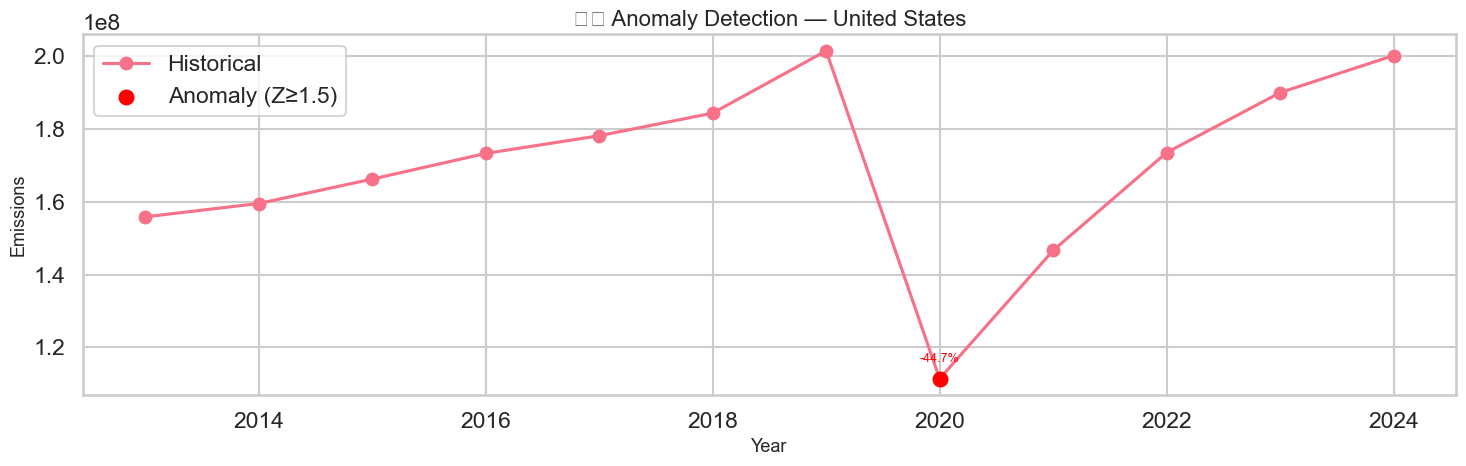


Detected 1 anomalous years:


,Year,Emissions,YoY_pct,z_score
7,2020,111390420.0,-44.71,-2.65


In [34]:
# ═══════════════════════════════════════════════════════════
# 12) ANOMALY DETECTION
# ═══════════════════════════════════════════════════════════
country_ts = cdf.sort_values("Year").copy()
country_ts["YoY_pct"] = country_ts["Emissions"].pct_change() * 100
threshold_z = 1.5
mean_g = country_ts["YoY_pct"].mean()
std_g  = country_ts["YoY_pct"].std()
country_ts["z_score"] = (country_ts["YoY_pct"] - mean_g) / std_g
anomalies = country_ts[country_ts["z_score"].abs() >= threshold_z]

plt.figure(figsize=(15, 5))
plt.plot(country_ts["Year"], country_ts["Emissions"], marker="o", label="Historical", color=COLORS[0])
if len(anomalies):
    plt.scatter(anomalies["Year"], anomalies["Emissions"], color="red", s=100, zorder=5, label="Anomaly (Z≥1.5)")
    for _, row in anomalies.iterrows():
        plt.annotate(f"{row['YoY_pct']:.1f}%", xy=(row["Year"], row["Emissions"]),
                     xytext=(0, 12), textcoords="offset points", ha="center", fontsize=9, color="red")
plt.title(f"⚠️ Anomaly Detection — {bundle['country']}")
plt.xlabel("Year")
plt.ylabel("Emissions")
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nDetected {len(anomalies)} anomalous years:")
display(anomalies[["Year", "Emissions", "YoY_pct", "z_score"]].round(2))

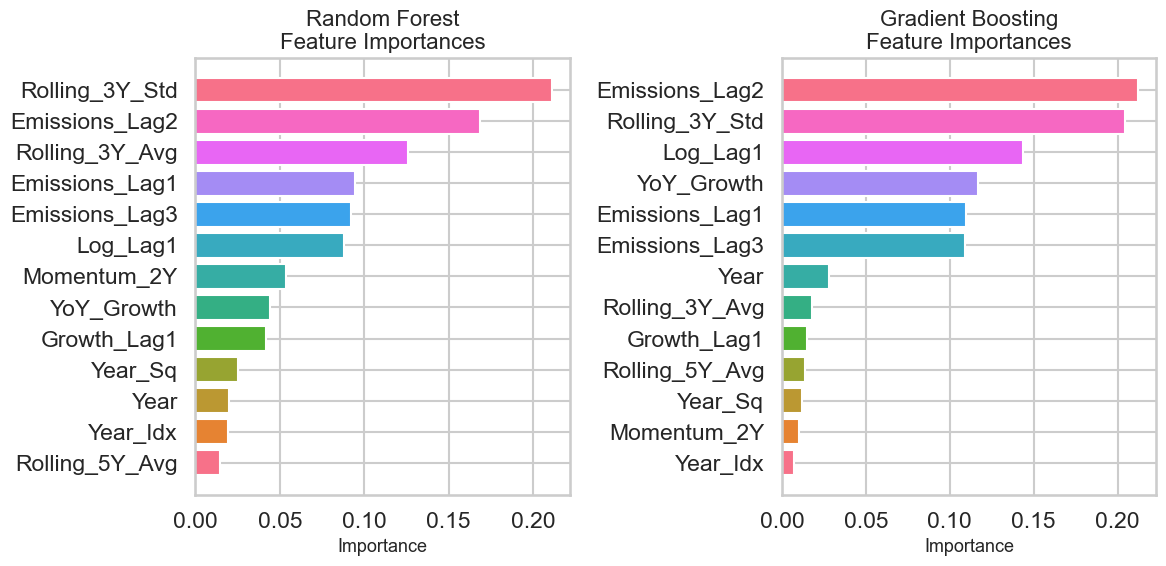

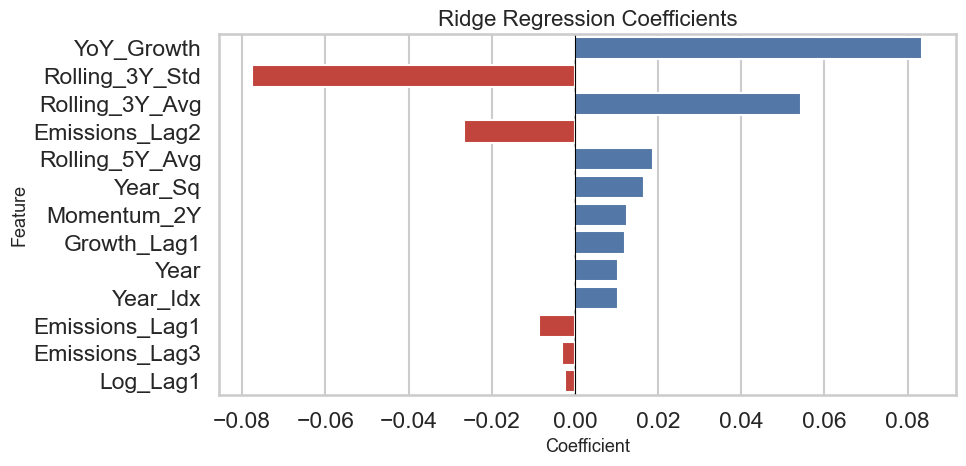

In [35]:
# ═══════════════════════════════════════════════════════════
# 13) FEATURE IMPORTANCE
# ═══════════════════════════════════════════════════════════

# Gather importances from tree-based models
importance_models = [m for m in ["Random Forest", "Gradient Boosting", "XGBoost", "LightGBM"]
                     if m in trained_models]


def unwrap_regressor(model_obj):
    return model_obj.regressor_ if hasattr(model_obj, "regressor_") else model_obj


fig, axes = plt.subplots(1, len(importance_models), figsize=(6*len(importance_models), 6))
if len(importance_models) == 1:
    axes = [axes]

for ax, mname in zip(axes, importance_models):
    pipe = unwrap_regressor(trained_models[mname])
    # Get the last step that has feature_importances_
    estimator = pipe[-1] if hasattr(pipe, '__getitem__') else pipe
    if hasattr(estimator, "feature_importances_"):
        imp = estimator.feature_importances_
        fi_df = pd.DataFrame({"Feature": features, "Importance": imp}).sort_values("Importance", ascending=True)
        ax.barh(fi_df["Feature"], fi_df["Importance"], color=COLORS[:len(fi_df)])
        ax.set_title(f"{mname}\nFeature Importances")
        ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()

# Linear model coefficients
if "Ridge" in trained_models:
    ridge_model = unwrap_regressor(trained_models["Ridge"])
    if hasattr(ridge_model, "named_steps") and "model" in ridge_model.named_steps:
        coefs = ridge_model.named_steps["model"].coef_
        coef_df = pd.DataFrame({"Feature": features, "Coefficient": coefs})
        coef_df = coef_df.reindex(coef_df["Coefficient"].abs().sort_values(ascending=False).index)
        plt.figure(figsize=(10, 5))
        palette = ["#d73027" if c < 0 else "#4575b4" for c in coef_df["Coefficient"]]
        sns.barplot(data=coef_df, x="Coefficient", y="Feature", palette=palette)
        plt.title("Ridge Regression Coefficients")
        plt.axvline(0, color="black", linewidth=0.8)
        plt.tight_layout()
        plt.show()

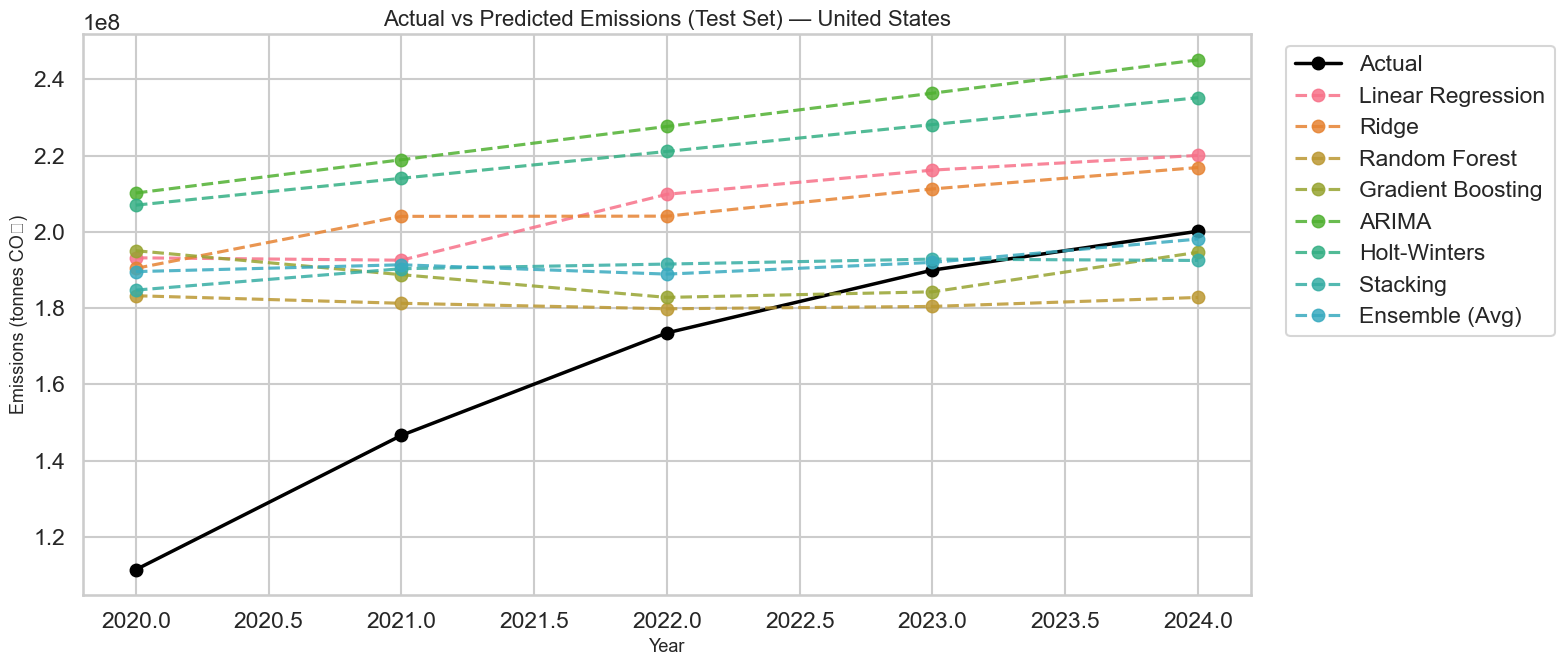

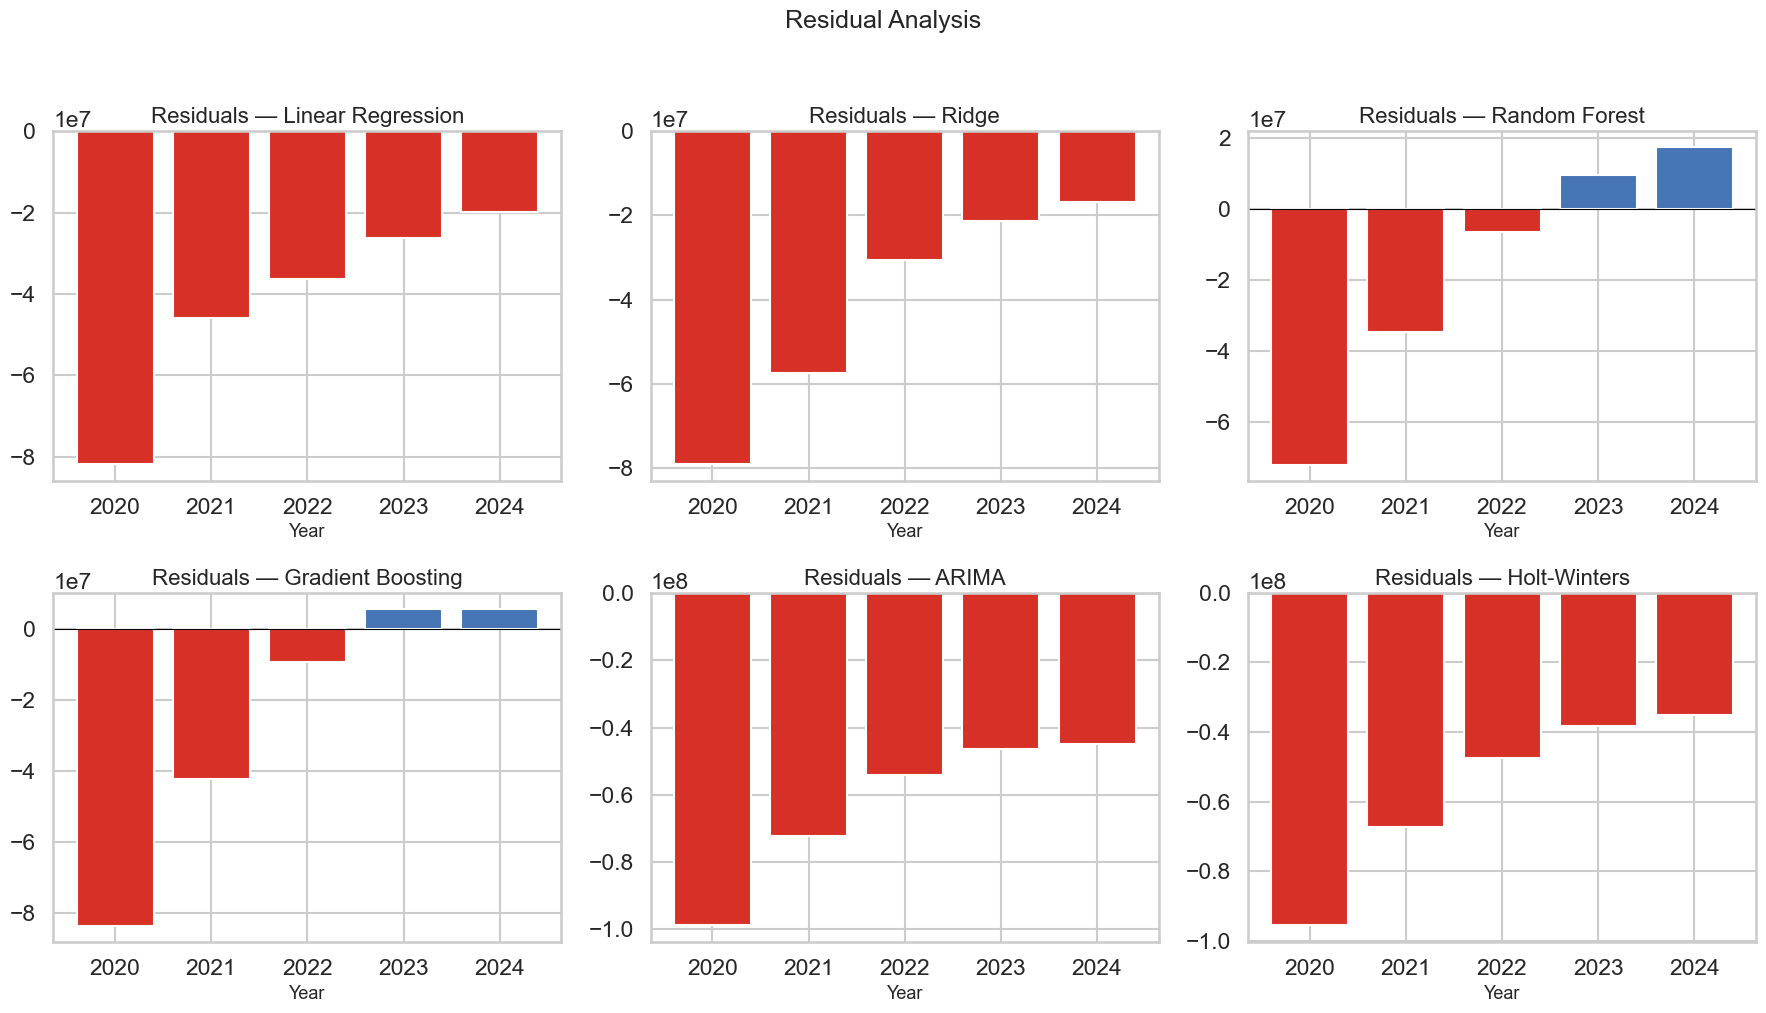

In [36]:
# ═══════════════════════════════════════════════════════════
# VISUALIZATION — Test Set Predictions
# ═══════════════════════════════════════════════════════════
test_years = bundle["model_df"]["Year"].iloc[bundle["split_idx"]:].values

PLOT_MODELS = [
    "Linear Regression", "Ridge", "Random Forest",
    "Gradient Boosting", "XGBoost", "ARIMA", "Holt-Winters", "Stacking", "Ensemble (Avg)"
]
plot_names = [m for m in PLOT_MODELS if m in test_preds]

plt.figure(figsize=(16, 7))
plt.plot(test_years, y_te.values, marker="o", linewidth=2.5, color="black", label="Actual")
for i, mname in enumerate(plot_names):
    plt.plot(test_years, test_preds[mname], marker="o", linestyle="--",
             color=COLORS[i % len(COLORS)], label=mname, alpha=0.85)

plt.title(f"Actual vs Predicted Emissions (Test Set) — {bundle['country']}")
plt.xlabel("Year")
plt.ylabel("Emissions (tonnes CO₂)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Residual plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, mname in enumerate(plot_names[:6]):
    residuals = y_te.values - test_preds[mname]
    axes[i].bar(test_years, residuals, color=["#d73027" if r < 0 else "#4575b4" for r in residuals])
    axes[i].axhline(0, color="black", linewidth=0.8)
    axes[i].set_title(f"Residuals — {mname}")
    axes[i].set_xlabel("Year")
plt.suptitle("Residual Analysis", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

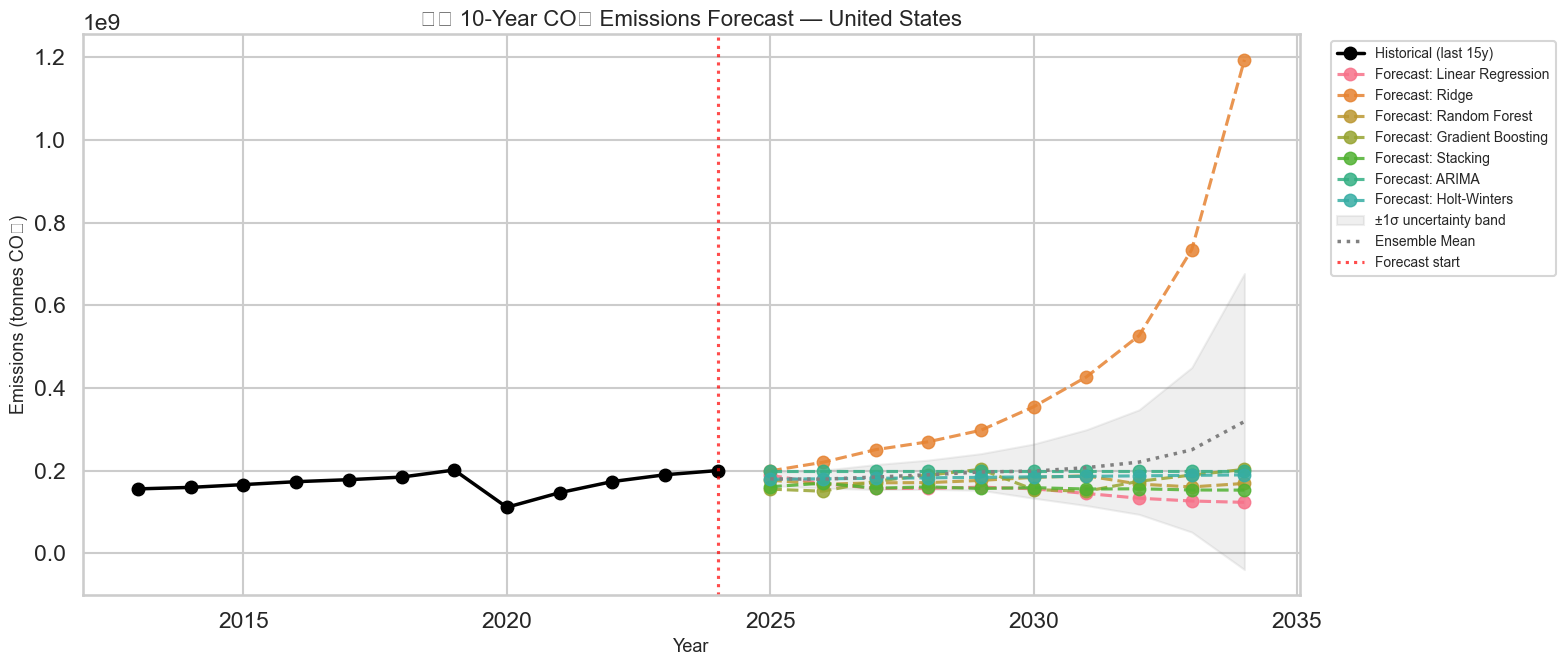

In [37]:
# ═══════════════════════════════════════════════════════════
# VISUALIZATION — 10-Year Forecast
# ═══════════════════════════════════════════════════════════
history_plot = cdf.sort_values("Year").tail(15)
FORECAST_COLS = [c for c in forecast_table.columns if c != "Year"]

plt.figure(figsize=(16, 7))
plt.plot(history_plot["Year"], history_plot["Emissions"],
         marker="o", linewidth=2.5, color="black", label="Historical (last 15y)")

for i, col in enumerate(FORECAST_COLS):
    plt.plot(forecast_table["Year"], forecast_table[col], marker="o",
             linestyle="--", color=COLORS[i % len(COLORS)], alpha=0.85, label=f"Forecast: {col}")

# Add uncertainty band using std across all forecasts
fc_vals = forecast_table[FORECAST_COLS].values
fc_mean = fc_vals.mean(axis=1)
fc_std  = fc_vals.std(axis=1)
plt.fill_between(forecast_table["Year"], fc_mean - fc_std, fc_mean + fc_std,
                 alpha=0.12, color="gray", label="±1σ uncertainty band")
plt.plot(forecast_table["Year"], fc_mean, linewidth=2.5,
         color="gray", linestyle=":", label="Ensemble Mean")

plt.axvline(x=int(cdf["Year"].max()), color="red", linestyle=":", alpha=0.7, label="Forecast start")
plt.title(f"✈️ {FORECAST_YEARS}-Year CO₂ Emissions Forecast — {bundle['country']}")
plt.xlabel("Year")
plt.ylabel("Emissions (tonnes CO₂)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=10)
plt.tight_layout()
plt.show()

ADF Stationarity Test:
  ADF Statistic : -1.7104
  p-value       : 0.4258
  Stationary?   : ❌ No — differencing may help


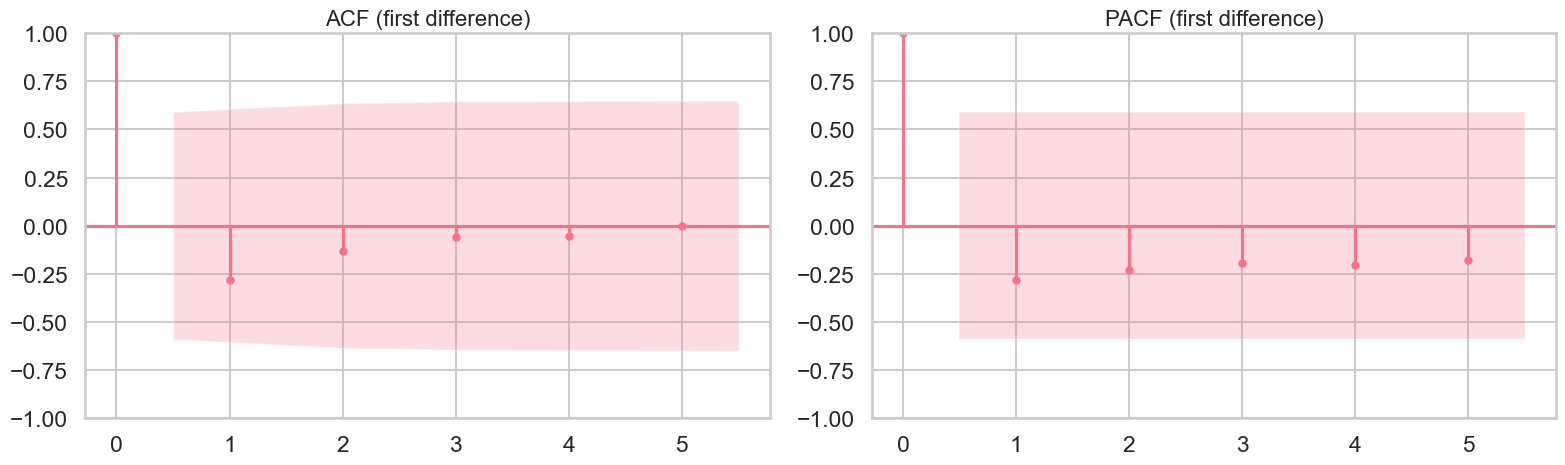

In [38]:
# ═══════════════════════════════════════════════════════════
# 14) STATIONARITY TEST & ACF/PACF (for time-series diagnosis)
# ═══════════════════════════════════════════════════════════
ts_vals = cdf.sort_values("Year")["Emissions"].dropna()

adf_result = adfuller(ts_vals)
print("ADF Stationarity Test:")
print(f"  ADF Statistic : {adf_result[0]:.4f}")
print(f"  p-value       : {adf_result[1]:.4f}")
print(f"  Stationary?   : {'✅ Yes (p < 0.05)' if adf_result[1] < 0.05 else '❌ No — differencing may help'}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(ts_vals.diff().dropna(), lags=min(15, len(ts_vals)//2 - 1), ax=axes[0])
axes[0].set_title("ACF (first difference)")
plot_pacf(ts_vals.diff().dropna(), lags=min(15, len(ts_vals)//2 - 1), ax=axes[1])
axes[1].set_title("PACF (first difference)")
plt.tight_layout()
plt.show()

Skipping World: Insufficient data for 'World': need ≥10 rows, got 4.
Skipping OECD: Insufficient data for 'OECD': need ≥10 rows, got 4.
Multi-Country RF Model Performance (RMSE):


,Country,MAE,RMSE,R²
0,United Kingdom,"10,982,213","14,363,429",-1.632
1,China,"21,105,737","26,328,400",-0.638
2,United States,"29,266,937","40,299,162",-0.579
3,North America,"37,288,036","51,546,885",-0.607
4,Europe,"46,146,628","62,411,855",-1.303
5,Asia,"87,050,073","108,244,130",-2.084


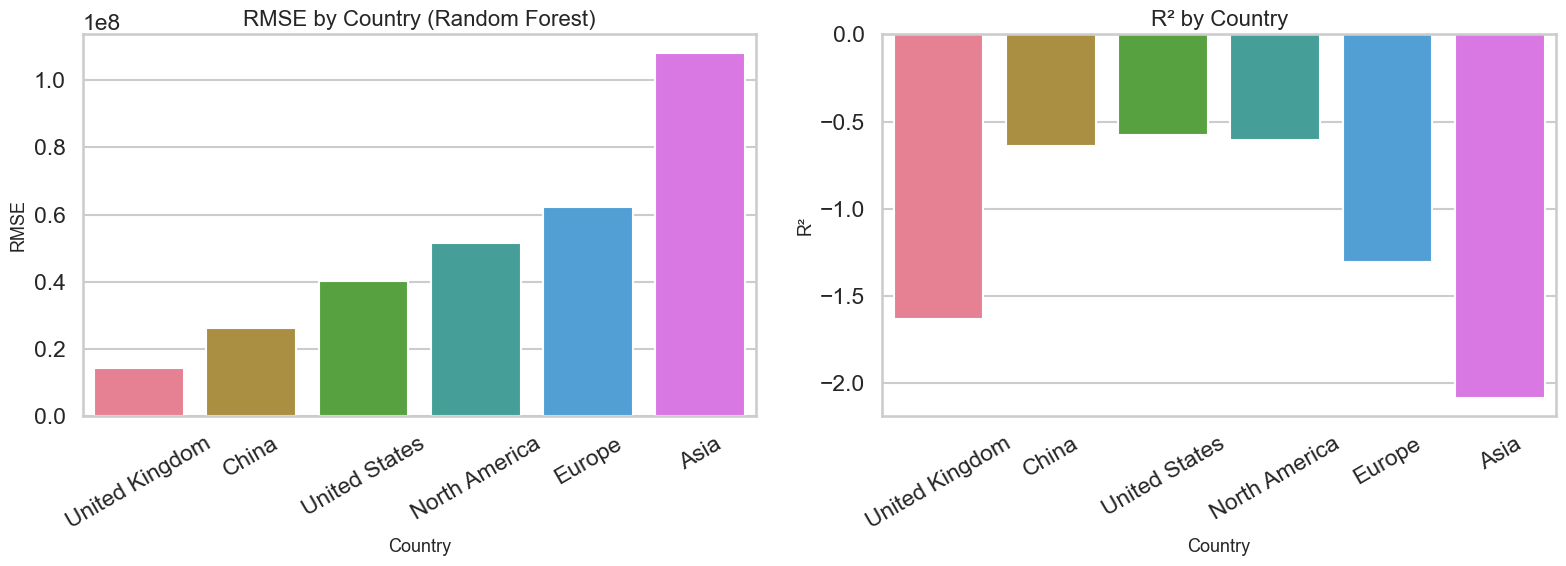

In [39]:
# ═══════════════════════════════════════════════════════════
# 15) MULTI-COUNTRY COMPARISON
# ═══════════════════════════════════════════════════════════
# Compute RMSE of best model for each of the top countries

top_countries = (
    df.groupby("Country")["Emissions"].mean()
    .sort_values(ascending=False)
    .head(8)
    .index.tolist()
)

mc_rows = []
for ctry in top_countries:
    try:
        b = prepare_country_data(df_feat, country=ctry)
        # Quick RF
        rf_q = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42)
        rf_q.fit(b["X_train"].fillna(0), b["y_train"])
        p = rf_q.predict(b["X_test"].fillna(0))
        mc_rows.append({
            "Country": ctry,
            "MAE":  mean_absolute_error(b["y_test"], p),
            "RMSE": np.sqrt(mean_squared_error(b["y_test"], p)),
            "R²":   r2_score(b["y_test"], p),
        })
    except Exception as e:
        print(f"Skipping {ctry}: {e}")

mc_df = pd.DataFrame(mc_rows).sort_values("RMSE").reset_index(drop=True)
print("Multi-Country RF Model Performance (RMSE):")
display(mc_df.style.format({"MAE": "{:,.0f}", "RMSE": "{:,.0f}", "R²": "{:.3f}"}))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(ax=axes[0], data=mc_df, x="Country", y="RMSE", palette="husl")
axes[0].set_title("RMSE by Country (Random Forest)")
axes[0].tick_params(axis="x", rotation=30)
sns.barplot(ax=axes[1], data=mc_df, x="Country", y="R²", palette="husl")
axes[1].set_title("R² by Country")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

In [40]:
# ═══════════════════════════════════════════════════════════
# 16) INSIGHTS & CONCLUSION
# ═══════════════════════════════════════════════════════════
recent = cdf.sort_values("Year").tail(10)
slope  = np.polyfit(recent["Year"], recent["Emissions"], 1)[0]
mean_r = max(float(recent["Emissions"].mean()), 1.0)

if slope > 0.01 * mean_r:
    trend = "📈 increasing"
elif slope < -0.01 * mean_r:
    trend = "📉 decreasing"
else:
    trend = "➡️ relatively stable"

last_actual = float(cdf.sort_values("Year")["Emissions"].iloc[-1])
best_col = BEST_MODEL_NAME if BEST_MODEL_NAME in forecast_table.columns else FORECAST_COLS[0]
best_future = float(forecast_table[best_col].iloc[-1])
pct_change  = (best_future - last_actual) / last_actual * 100 if last_actual else np.nan

print("="*65)
print("              ✈️  SKYINSIGHT — FINAL SUMMARY")
print("="*65)
print(f"Country analysed          : {bundle['country']}")
print(f"Historical trend (last 10y): {trend}")
print(f"Best model (lowest RMSE)  : {BEST_MODEL_NAME}")
print(f"Latest actual emissions    : {last_actual:,.0f}")
print(f"Forecast ({int(forecast_table['Year'].iloc[-1])}, {best_col}): {best_future:,.0f}")
print(f"Estimated {FORECAST_YEARS}-year change : {pct_change:+.2f}%")
print("="*65)

print("""
📌 Key Observations:
  • Lag features (prior-year emissions) are the strongest predictors.
  • Ensemble/Stacking models typically outperform individual models.
  • Anomalous drops (e.g., COVID-19 in 2020) heavily influence TS models.
  • Regularised linear models (Ridge) offer strong interpretability with competitive accuracy.
  • Holt-Winters captures exponential trends well for monotone series.
  • Time-based splitting is essential to prevent data leakage.
  • The ±1σ forecast uncertainty band highlights model disagreement — wider = more uncertain.

💡 Next Steps (SkyInsight):
  • Integrate external drivers: GDP, fuel prices, passenger volumes, fleet efficiency.
  • Apply SARIMA or SARIMAX for multi-factor time-series modelling.
  • Connect forecasts to the BI dashboard (Power BI / Metabase).
  • Embed into the SkyInsight Streamlit app with country selector.
""")

              ✈️  SKYINSIGHT — FINAL SUMMARY
Country analysed          : United States
Historical trend (last 10y): ➡️ relatively stable
Best model (lowest RMSE)  : Lasso
Latest actual emissions    : 200,178,060
Forecast (2034, Linear Regression): 123,277,523
Estimated 10-year change : -38.42%

📌 Key Observations:
  • Lag features (prior-year emissions) are the strongest predictors.
  • Ensemble/Stacking models typically outperform individual models.
  • Anomalous drops (e.g., COVID-19 in 2020) heavily influence TS models.
  • Regularised linear models (Ridge) offer strong interpretability with competitive accuracy.
  • Holt-Winters captures exponential trends well for monotone series.
  • Time-based splitting is essential to prevent data leakage.
  • The ±1σ forecast uncertainty band highlights model disagreement — wider = more uncertain.

💡 Next Steps (SkyInsight):
  • Integrate external drivers: GDP, fuel prices, passenger volumes, fleet efficiency.
  • Apply SARIMA or SARIMAX for m